<a href="https://colab.research.google.com/github/SMTorg/smt-notebooks/blob/master/SMT_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="jumbotron text-left"><b>
This tutorial describes how to use the SMT toolbox, which is a python toolbox for building a surrogate model.</b></div>

Nathalie BARTOLI ONERA/DTIS/M2CI - June 2026

based on `SMT 2.14.1 version`

<div class="alert alert-info fade in" id="d110">
<strong> Latest updates  </strong>
<ol> -  example to use Kriging with cooperative components (CoopCompKRG in high dimension for optimization of hyperparameters) - see Section 4.4 </ol>
 <ol> - use of the power exponential kernel (to improve the condition number of the correlation matrix, see this paper `Zimmermann, R. (2015). On the condition number anomaly of Gaussian correlation matrices. Linear Algebra and its Applications, 466, 512-526`)  </ol>

    
<strong>Previous updates</strong>
<ol> -  example to save and load models with binary format</ol>
<ol> -  predicted variance as a metric  </ol>
<ol> -  sparse gaussian process for large database </ol>
<ol> - use GPX build in Rust in order to reduce time for trining and prediction (KRG or KPLS models) </ol>
<ol> - correct the figures with matplotlib:  ax =  fig.add_subplot(projection='3d') </ol>
<ol> - prediction and variance derivatives for different kernels (squared exponential, absolute exponential, matern 32, matern 52) and trends (constant, linear) </ol>
<ol> -  Kriging with integer variables </ol>   
<ol> -  compare different covariance kernels for the kriging models </ol>
<ol> -  automatic choice of PLS comonents </ol>
<ol> -  example to use Marginal Gaussian Process   </ol>    
<ol> -  example to use multiple outputs (independant outputs) </ol>
<ol> -  example to compare models using Mixture of experts technique  </ol>  
<ol> -  example to save and load models using  `pickle`  </ol>    

</div>

<p class="alert alert-success" style="padding:1em">
To use SMT models, please follow this link : https://github.com/SMTorg/SMT/blob/master/README.md. The documentation is available here: http://smt.readthedocs.io/en/latest/
</p>

The reference paper is available
here https://www.sciencedirect.com/science/article/pii/S0965997818309360?via%3Dihub

or as a preprint: https://www.researchgate.net/profile/Mohamed_Amine_Bouhlel/publication/331976718_A_Python_surrogate_modeling_framework_with_derivatives/links/5cc3cebd299bf12097829631/A-Python-surrogate-modeling-framework-with-derivatives.pdf

Cite us:

M.-A. Bouhlel, J. T. Hwang, N. Bartoli, R. Lafage, J. Morlier, J .R.R.A Martins (2019), A Python surrogate modeling framework with derivatives, Advances in Engineering Software, 102662

P. Saves, R. Lafage, N. Bartoli, Y. Diouane, J. Bussemaker, T. Lefebvre, J. T. Hwang, J. Morlier, J. RRA. Martins (2024). SMT 2.0: A Surrogate Modeling Toolbox with a focus on hierarchical and mixed variables Gaussian processes. Advances in Engineering Software, 188, 103571.

<div class="alert alert-danger" >
<p> In most of the surrogate models $y\in\mathbb{R}$, so if you have multiple outputs $y\in\mathbb{R}^d$ (which are considered as independant outputs), add an external loop to build one surrogate model per output. The correlations betweens outputs are not taken into account. Section 11 of this notebook presents an example with 2 outputs.
</div>

<div class="alert alert-warning" >
In this notebook, the database is considered to be noise-free. If you want to consider noisy data, please have a look at the dedicated notebook available within SMT.
</div>


In [1]:
# to install smt
%pip install smt
# to reduce CPU time
%pip install numba

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import smt

print("SMT Version", smt.__version__)

SMT Version 2.12.1.dev6+g5e0f33bfe.d20260619


<div class="alert alert-warning" >
If you use hierarchical variables and the size of your doe greater than 30 points, you may leverage the `numba` JIT compiler to speed up the computation
To do so:
    
 - install numba library
    
     `pip install numba`
    
    
 - and define the environment variable `USE_NUMBA_JIT = 1` (unset or 0 if you do not want to use numba)
    
     - Linux: export USE_NUMBA_JIT = 1
    
     - Windows: set USE_NUMBA_JIT = 1

</div>

In [3]:
# to check if numba is available
!pip show numba
# and then you need to define the environment variable USE_NUMBA_JIT
!echo "Numba used or not in your environment=" %USE_NUMBA_JIT%

Name: numba
Version: 0.64.0
Summary: compiling Python code using LLVM
Home-page: https://numba.pydata.org
Author: 
Author-email: 
License: BSD
Location: D:\rlafage\miniconda3\Lib\site-packages
Requires: llvmlite, numpy
Required-by: adsg-core


"Numba used or not in your environment=" %USE_NUMBA_JIT%


# 0. Construction of the DOE points

In [4]:
import numpy as np
from smt.utils.misc import compute_relative_error

from smt.problems import Rosenbrock
from smt.sampling_methods import LHS
from smt.surrogate_models import LS, QP, KPLS, KRG, KPLSK, GEKPLS, MGP

try:
    from smt.surrogate_models import IDW, RBF, RMTC, RMTB

    compiled_available = True
except Exception:
    compiled_available = False

try:
    import matplotlib.pyplot as plt

    plot_status = True
except Exception:
    plot_status = False


import matplotlib.pyplot as plt
from matplotlib import cm


# to ignore warning messages
import warnings

warnings.filterwarnings("ignore")

## Rosenbrock Function  in dimension N

$$
f(\mathbf{x}) = \sum_{i=1}^{N-1} 100 (x_{i+1} - x_i^2 )^2 + (1-x_i)^2 \quad \text{where} \quad \mathbf{x} = [x_1, \ldots, x_N] \in \mathbb{R}^N.
$$

$$x_i \in [-2,2]$$
    

## Training points and validation points using a LHS algorithm

Here we outline the studied function by plotting the surface representing the function. In addition, we plot also the training points used later to build the surrogate model as well as the validation points which will be used to evaluate the quality of the surrogate model. Both the training point and validation points are generated by a LHS DOE algorithm.

<div class="alert alert-danger" >
<p> In order to have reproducibility of the tests and results, we use  the option `seed` to set a seed to the random generator, so that your DOE points are always deterministic. If you don't set a seed, it is different each time.
</div>

In [5]:
########### Initialization of the problem, construction of the training and validation points

ndim = 2
ndoe = 20  # int(10*ndim)
# Define the function
fun = Rosenbrock(ndim=ndim)

# Construction of the DOE
# in order to have the always same LHS points, seed=1
sampling = LHS(xlimits=fun.xlimits, criterion="ese", seed=1)
xt = sampling(ndoe)
# Compute the outputs
yt = fun(xt)[:, 0]  # yt is a vector

# Construction of the validation points
ntest = 200  # 500
sampling = LHS(xlimits=fun.xlimits, criterion="ese", seed=1)
xtest = sampling(ntest)
ytest = fun(xtest)[:, 0]  # ytest is a vector

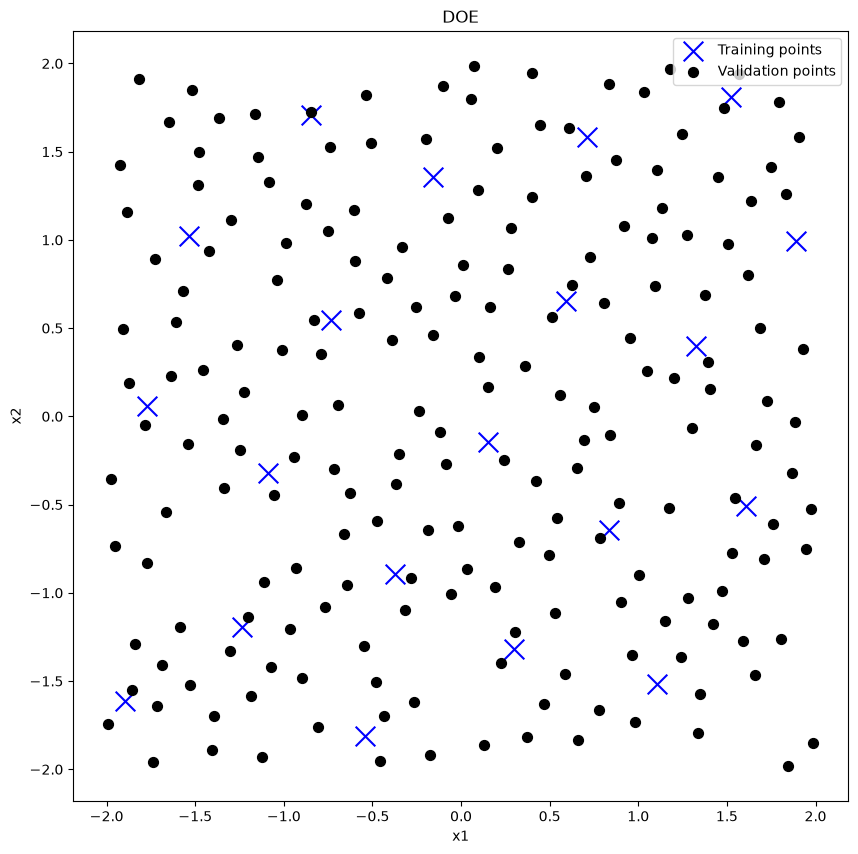

In [6]:
# To visualize the DOE points
fig = plt.figure(figsize=(10, 10))
plt.scatter(xt[:, 0], xt[:, 1], marker="x", c="b", s=200, label="Training points")
plt.scatter(
    xtest[:, 0], xtest[:, 1], marker=".", c="k", s=200, label="Validation points"
)
plt.title("DOE")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

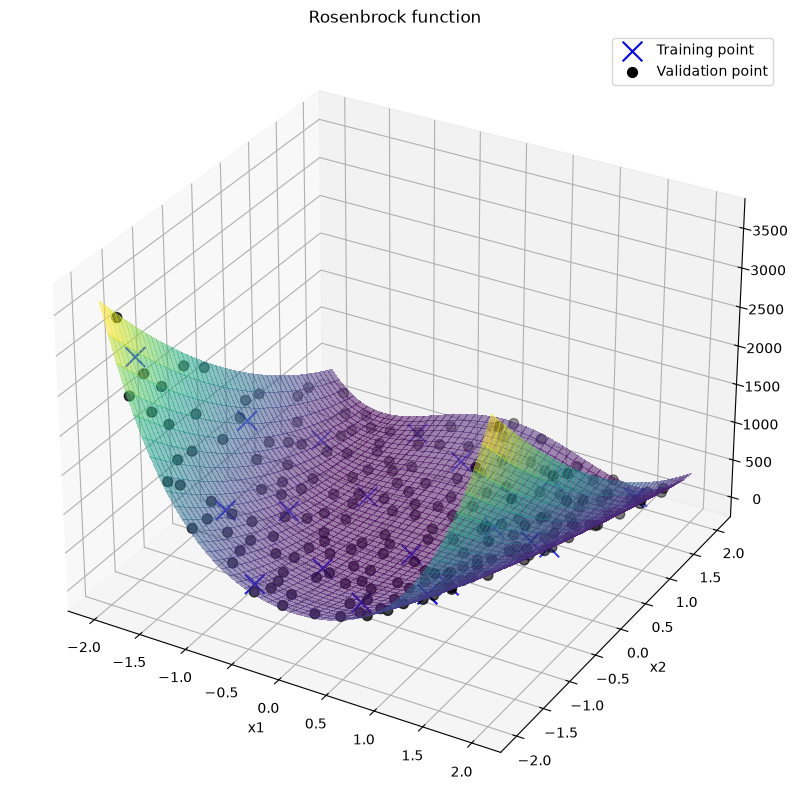

In [7]:
# To plot the Rosenbrock function
x = np.linspace(-2, 2, 50)
res = []
for x0 in x:
    for x1 in x:
        res.append(fun(np.array([[x0, x1]])))
res = np.array(res)
res = res.reshape((50, 50)).T
X, Y = np.meshgrid(x, x)
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(
    X, Y, res, cmap=cm.viridis, linewidth=0, antialiased=False, alpha=0.5
)

ax.scatter(
    xt[:, 0], xt[:, 1], yt, zdir="z", marker="x", c="b", s=200, label="Training point"
)
ax.scatter(
    xtest[:, 0],
    xtest[:, 1],
    ytest,
    zdir="z",
    marker=".",
    c="k",
    s=200,
    label="Validation point",
)

plt.title("Rosenbrock function")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

Different models will be used and compared:

- Linear Model (first order polynomial)
- Quadratic Model (second order polynomial)
- Kriging Model (also known as Gaussian Process)
- KPLS Model and KPLSK Model (useful for Kriging in high dimension)
- IDW Model (Inverse Distance Weighting)
- RBF Model (Radial Basis Function)
- RMTS Models: RMTB and RMTC (useful for low dimensional problem)

Some metrics to assess some errors are proposed at the end.

Mixture of experts technique will be used to compare different surrogate models.

# 1. Linear Model

___________________________________________________________________________
   
                                    LS
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
   Training - done. Time (sec):  0.0154550
LS,  err: 0.7150423522303335


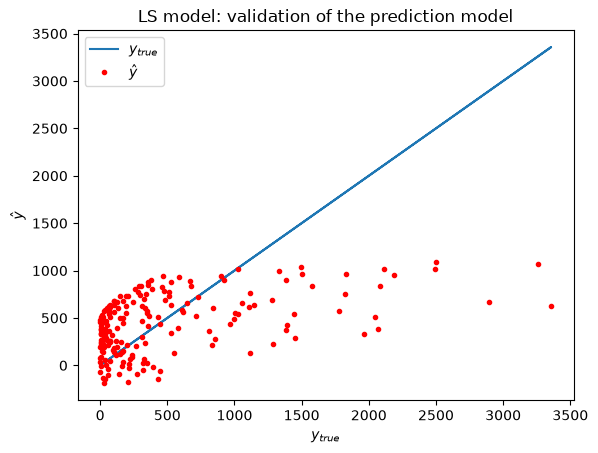

In [8]:
########### The LS model

# Initialization of the model
t = LS(print_prediction=False)

# Add the DOE
t.set_training_values(xt, yt)

# Train the model
t.train()

# Prediction of the validation points
y = t.predict_values(xtest)
print("LS,  err: " + str(compute_relative_error(t, xtest, ytest)))

# Plot prediction/true values
if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title("LS model: validation of the prediction model")

# 2. Quadratic Model

___________________________________________________________________________
   
                                    QP
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
   Training - done. Time (sec):  0.0009646
QP,  err: 0.4336103418811051


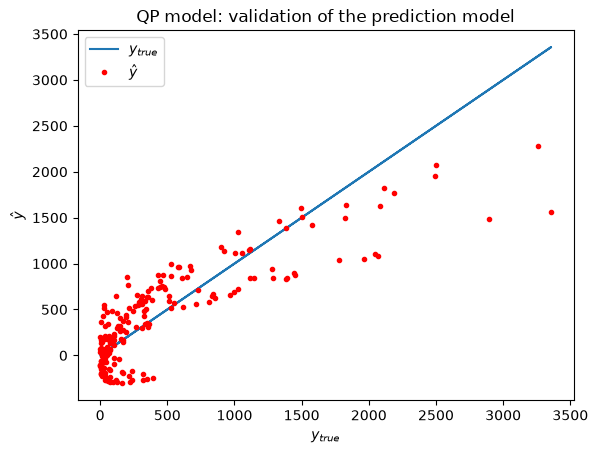

In [9]:
########### The QP model

t = QP(print_prediction=False)
t.set_training_values(xt, yt)

t.train()

# Prediction of the validation points
y = t.predict_values(xtest)
print("QP,  err: " + str(compute_relative_error(t, xtest, ytest)))

# Plot prediction/true values
if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title("QP model: validation of the prediction model")

# 3. Kriging Model

___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.7231829
Kriging,  err: 0.0005183506370863989


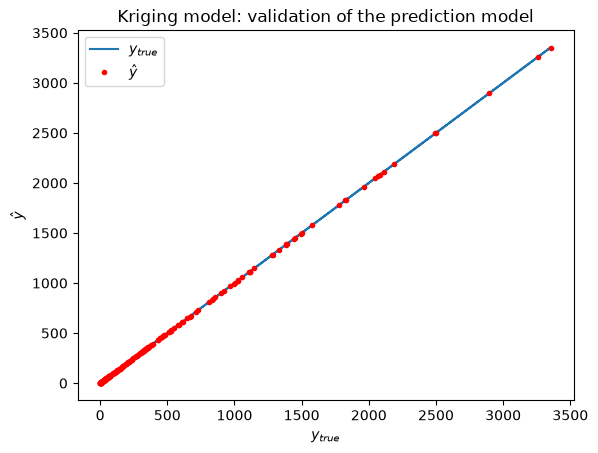

theta values [0.02359944 0.00010136]


In [10]:
########### The Kriging model

# The variable 'theta0' is a list of length ndim.
t = KRG(theta0=[1e-2] * ndim, print_prediction=False)
t.set_training_values(xt, yt)

t.train()

# Prediction of the validation points
y = t.predict_values(xtest)
print("Kriging,  err: " + str(compute_relative_error(t, xtest, ytest)))
if plot_status:
    # Plot the function and the prediction
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title("Kriging model: validation of the prediction model")

if plot_status:
    plt.show()

# Value of theta
print("theta values", t.optimal_theta)

Associated to the Kriging prediction, there is the estimated variance in order to have a confidence interval.


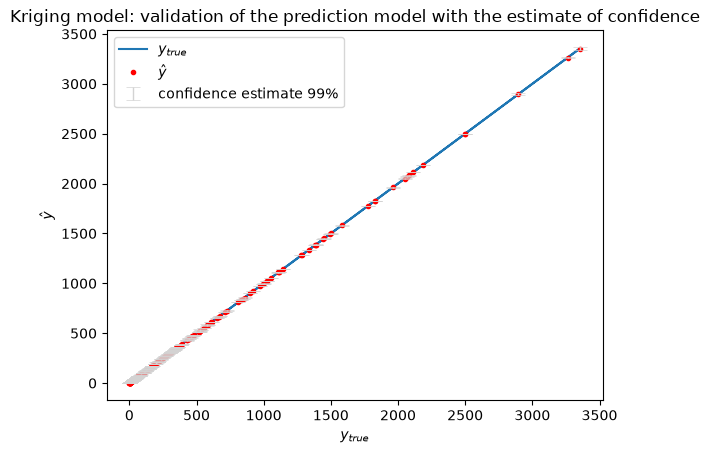

In [11]:
# estimated variance for the validation points
s2 = t.predict_variances(xtest)
# plot with the associated interval confidence
yerr = (
    2 * 3 * np.sqrt(s2)
)  # in order to use +/- 3 x standard deviation: 99% confidence interval estimation
if plot_status:
    # Plot the function, the prediction and the 99% confidence interval based on
    # the MSE
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")
    plt.errorbar(
        np.squeeze(ytest),
        np.squeeze(y),
        yerr=np.squeeze(yerr),
        fmt="none",
        capsize=5,
        ecolor="lightgray",
        elinewidth=1,
        capthick=0.5,
        label="confidence estimate 99%",
    )
    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        "Kriging model: validation of the prediction model with the estimate of confidence"
    )

if plot_status:
    plt.show()

You can also have access to the kriging derivative prediction


In [12]:
# estimated derivative for the validation points
dydx1 = t.predict_derivatives(xtest, 0)  # derivative according to the x1
dydx2 = t.predict_derivatives(xtest, 1)  # derivative according to the x2

In [13]:
# estimated variance derivative for the validation points
dsigmadx1 = t.predict_variance_derivatives(
    xtest, 0
)  # variance derivative according to the x1
dsigmadx2 = t.predict_variance_derivatives(
    xtest, 1
)  # variance derivative according to the x2

<div class="alert alert-info fade in" id="d110">
<p>The idea could be to compare different covariance kernels</p>
<ol> -  a squared exponential kernel (by default)  </ol>
<ol> -  an absolute exponential kernel   </ol>    
 <ol>   - use of the power exponential kernel </ol>  
<ol> - some Matern Kernels (matern 32 and matern 52) </ol>
</div>

In [14]:
# squared exponential by default
t1 = KRG(theta0=[1e-2] * ndim, print_prediction=False, corr="squar_exp")
t1.set_training_values(xt, yt)
t1.train()
# Prediction of the validation points
y1 = t1.predict_values(xtest)

# absolute exponential
t2 = KRG(theta0=[1e-2] * ndim, print_prediction=False, corr="abs_exp")
t2.set_training_values(xt, yt)
t2.train()
# Prediction of the validation points
y2 = t2.predict_values(xtest)

# matern32
t3 = KRG(theta0=[1e-2] * ndim, print_prediction=False, corr="matern32")
t3.set_training_values(xt, yt)
t3.train()
# Prediction of the validation points
y3 = t3.predict_values(xtest)

# matern52
t4 = KRG(theta0=[1e-2] * ndim, print_prediction=False, corr="matern52")
t4.set_training_values(xt, yt)
t4.train()
# Prediction of the validation points
y4 = t4.predict_values(xtest)


# power exponential kernell with power = 1.9
t5 = KRG(
    theta0=[1e-2] * ndim, print_prediction=False, corr="pow_exp", pow_exp_power=1.9
)
t5.set_training_values(xt, yt)
t5.train()
# Prediction of the validation points
y5 = t5.predict_values(xtest)


print("\n")
print("Comparison of errors")
print(
    "Kriging squared exponential,  err: "
    + str(compute_relative_error(t1, xtest, ytest))
)
print(
    "Kriging absolute exponential,  err: "
    + str(compute_relative_error(t2, xtest, ytest))
)
print("Kriging matern32,  err: " + str(compute_relative_error(t3, xtest, ytest)))
print("Kriging matern52,  err: " + str(compute_relative_error(t4, xtest, ytest)))
print(
    "Kriging power exponential,  err: " + str(compute_relative_error(t5, xtest, ytest))
)

___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.6802206
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.4540405
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.3076878
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.4696238
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.4487288


Comparison of errors
Kriging squared exponential,  err: 0.0005183506370863989
Kriging absolute exponential,  err: 0.3515220336072066
Kriging matern32,  err: 0.1646933880683154
Kriging matern52,  err: 0.0657256713658284
Kriging power exponential,  err: 0.1519527526330508


<div class="alert alert-info fade in" id="d110">
<p>Following the same idea, we can compare different  regression terms</p>
<ol> -  constant term  (by default)  </ol>
<ol> -  linear term  </ol>    
<ol> -  quadratic term </ol>
</div>

In [15]:
# squared exponential + constant term by default
t1 = KRG(
    theta0=[1e-2] * ndim, print_prediction=False, corr="squar_exp", poly="constant"
)
t1.set_training_values(xt, yt)
t1.train()
# Prediction of the validation points
y1 = t1.predict_values(xtest)

# squared exponential + linear term
t2 = KRG(theta0=[1e-2] * ndim, print_prediction=False, corr="squar_exp", poly="linear")
t2.set_training_values(xt, yt)
t2.train()
# Prediction of the validation points
y2 = t2.predict_values(xtest)

# squared exponential + quadratic term
t2 = KRG(
    theta0=[1e-2] * ndim, print_prediction=False, corr="squar_exp", poly="quadratic"
)
t2.set_training_values(xt, yt)
t2.train()
# Prediction of the validation points
y2 = t2.predict_values(xtest)


print("\n")
print("Comparison of errors")
print(
    "Kriging squared exponential + constant term,  err: "
    + str(compute_relative_error(t1, xtest, ytest))
)
print(
    "Kriging squared exponential + linear term,  err: "
    + str(compute_relative_error(t2, xtest, ytest))
)
print(
    "Kriging squared exponential + quadratic term,  err: "
    + str(compute_relative_error(t3, xtest, ytest))
)

___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.6983175
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.6398997
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.6597128


Comparison of errors
Kriging squared exponential + constant term,  err: 0.0005183506370863989
Kriging squared exponential + linear term,  err: 0.0003520472001561355
Kriging squared exponential + quadratic term,  err: 0.1646933880683154


## Visualization
Here we visualize the prediction using the Kriging surrogate. We can also plot the confidence interval using the estimated variance.

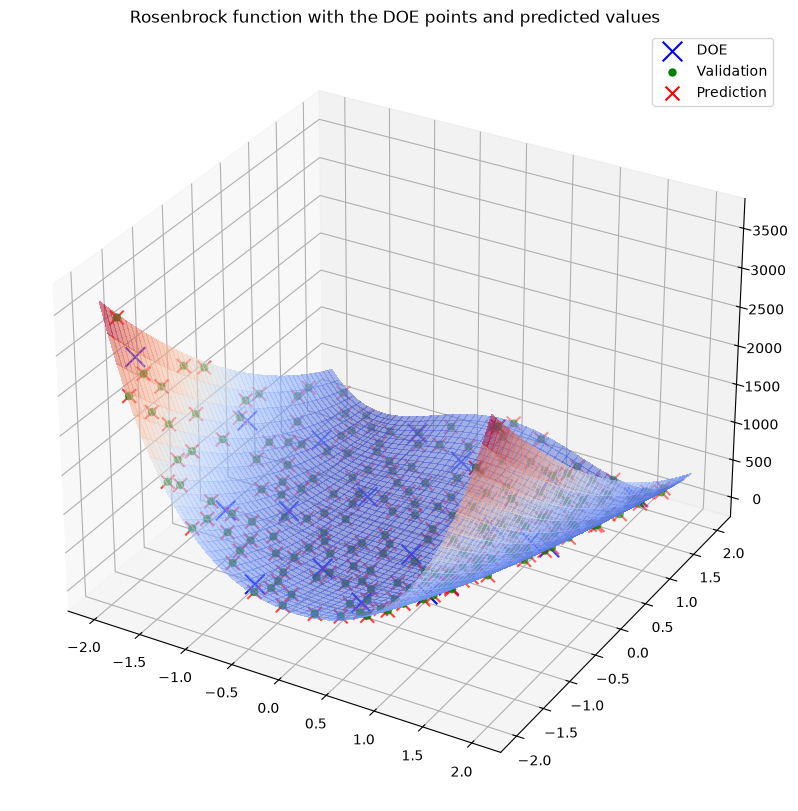

In [16]:
# Plot the surrogate model in 3D
x = np.linspace(-2, 2, 50)
resSM = []
varSM = []
for x0 in x:
    for x1 in x:
        resSM.append(t.predict_values(np.array([[x0, x1]])))
        varSM.append(t.predict_variances(np.array([[x0, x1]])))

resSM = np.array(resSM)
resSM = resSM.reshape((50, 50)).T
varSM = np.array(varSM)
varSM = varSM.reshape((50, 50)).T
X, Y = np.meshgrid(x, x)


fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection="3d")
ax.scatter(xt[:, 0], xt[:, 1], yt, zdir="z", marker="x", c="b", s=200, label="DOE")
surf = ax.plot_surface(
    X, Y, resSM, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.5
)
ax.scatter(
    xtest[:, 0],
    xtest[:, 1],
    ytest,
    zdir="z",
    marker=".",
    c="g",
    s=100,
    label="Validation",
)
ax.scatter(
    xtest[:, 0],
    xtest[:, 1],
    y[:, 0],
    zdir="z",
    marker="x",
    c="r",
    s=100,
    label="Prediction",
)
plt.legend()
plt.title("Rosenbrock function with the DOE points and predicted values")

plt.show()

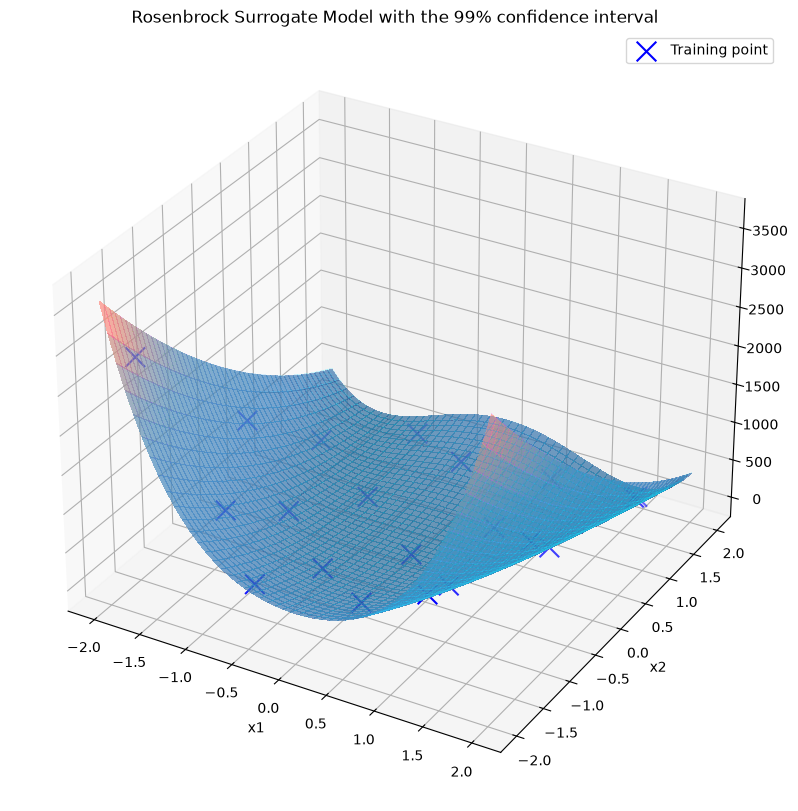

In [17]:
# Plot the surrogate with 99% confidence by using the estimated variance information
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(
    X, Y, resSM, cmap=cm.viridis, linewidth=0, antialiased=False, alpha=0.5
)
surf = ax.plot_surface(
    X,
    Y,
    resSM + 3 * np.sqrt(varSM),
    color="r",
    cmap=cm.cool,
    linewidth=0,
    antialiased=False,
    alpha=0.2,
)
surf = ax.plot_surface(
    X,
    Y,
    resSM - 3 * np.sqrt(varSM),
    color="r",
    cmap=cm.cool,
    linewidth=0,
    antialiased=False,
    alpha=0.2,
)


ax.scatter(
    xt[:, 0], xt[:, 1], yt, zdir="z", marker="x", c="b", s=200, label="Training point"
)
# ax.scatter(xtest[:,0],xtest[:,1],ytest,zdir='z',marker = '.',c='k',s=200,label='Validation point')

plt.title(" Rosenbrock Surrogate Model with the 99% confidence interval ")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

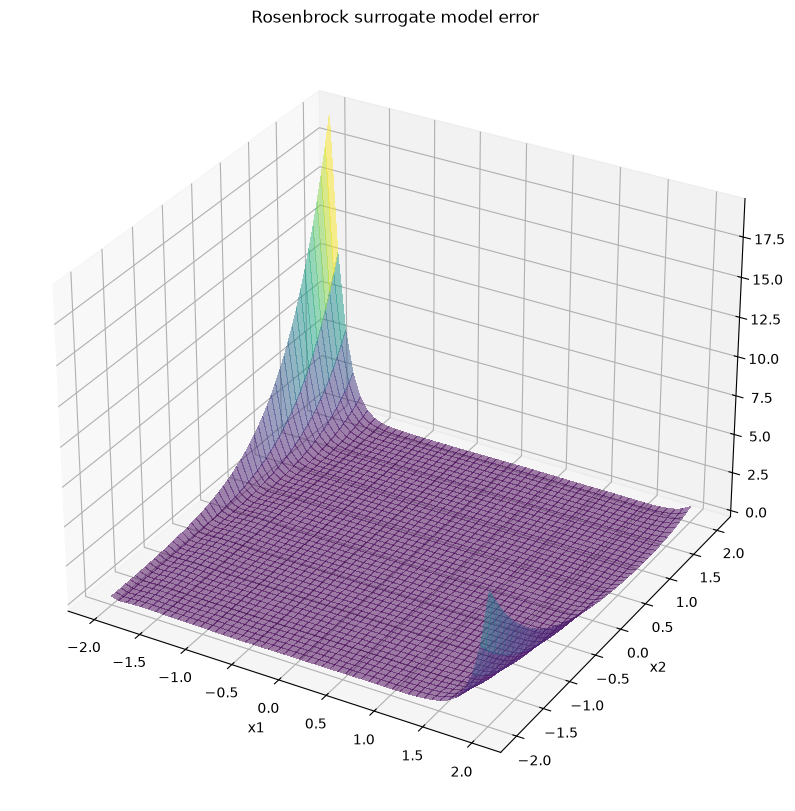

In [18]:
# Plot of the variance
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(
    X, Y, varSM, cmap=cm.viridis, linewidth=0, antialiased=False, alpha=0.5
)

plt.title("Rosenbrock surrogate model error")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# 4. KPLS and KPLSK Model

Here we implement the KPLS and KPLSK models (useful for high dimensional input space, approximatively greater than 10).

<div class="alert alert-warning">
<p>Only some covariance kernels are available for these models </p>
<ol> -  a squared exponential or an absolute exponential kernel for KPLS </ol>
<ol> -  a squared exponential  kernel for KPLSK </ol>    
</div>



## 4.1 KPLS Model

___________________________________________________________________________
   
                                   KPLS
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
   Training - done. Time (sec):  0.1227562
KPLS,  err: 0.3993478863521403


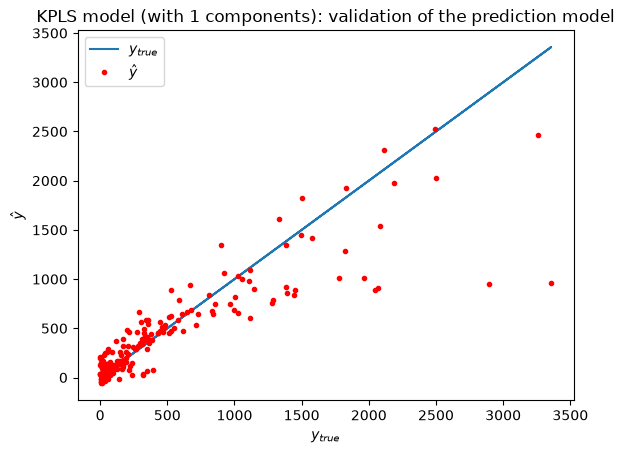

In [19]:
########### The KPLS model

# 'n_comp' and 'theta0' must be an integer in [1,ndim[ and a list of length n_comp, respectively.
n_comp = 1
t = KPLS(n_comp=n_comp, theta0=n_comp * [1e-2], print_prediction=False, corr="abs_exp")
t.set_training_values(xt, yt)

t.train()

# Prediction of the validation points
y = t.predict_values(xtest)
print("KPLS,  err: " + str(compute_relative_error(t, xtest, ytest)))

# plot prediction/true values
if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        f"KPLS model (with {n_comp} components): validation of the prediction model"
    )

if plot_status:
    plt.show()

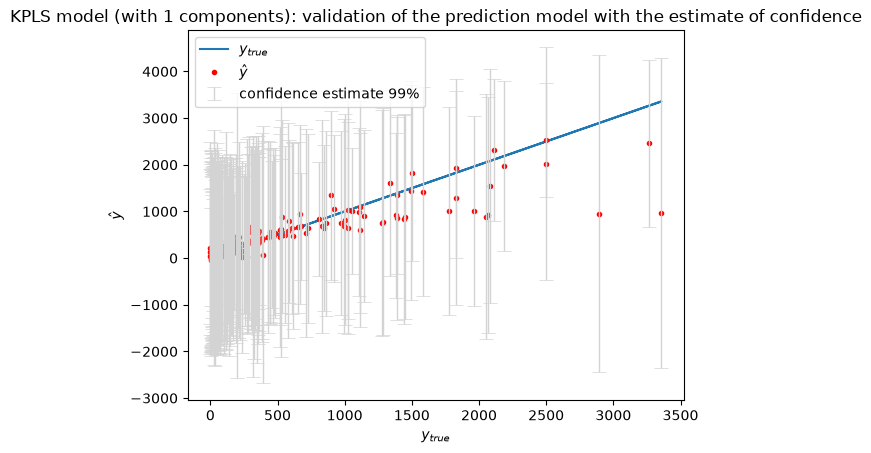

In [20]:
# estimated variance for the validation points
s2 = t.predict_variances(xtest)
# plot with the associated interval confidence
yerr = (
    2 * 3 * np.sqrt(s2)
)  # in order to use +/- 3 x standard deviation: 99% confidence interval estimation
if plot_status:
    # Plot the function, the prediction and the 99% confidence interval based on
    # the MSE
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")
    plt.errorbar(
        np.squeeze(ytest),
        np.squeeze(y),
        yerr=np.squeeze(yerr),
        fmt="none",
        capsize=5,
        ecolor="lightgray",
        elinewidth=1,
        capthick=0.5,
        label="confidence estimate 99%",
    )
    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        f"KPLS model (with {n_comp} components): validation of the prediction model with the estimate of confidence"
    )

if plot_status:
    plt.show()

## 4.2 Automatic selection of the number of components


___________________________________________________________________________
   
                                   KPLS
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  1.7898014

 --------------------------
 1 COMPONENTS FOUND OPTIMAL
 --------------------------

KPLS,  err: 0.3993478863521403


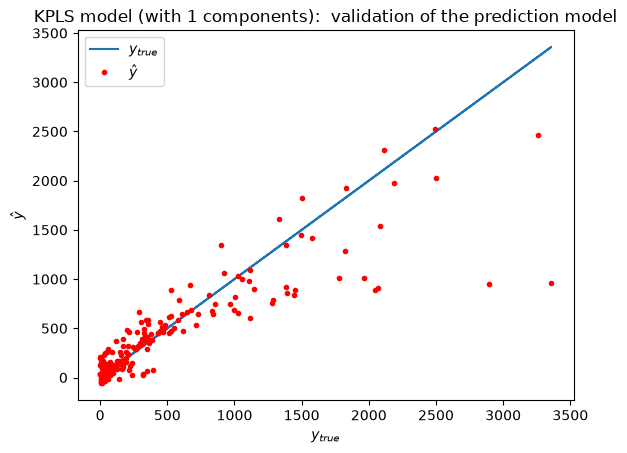

In [21]:
# 'n_comp' and 'theta0' must be an integer in [1,ndim[ and a list of length n_comp, respectively.
# 'eval_n_comp'  must be a boolean.

t = KPLS(eval_n_comp=True, print_prediction=False, corr="abs_exp")
t.set_training_values(xt, yt)

t.train()
l_comp = t.options["n_comp"]
print(
    "\n --------------------------\n",
    l_comp,
    "COMPONENTS FOUND OPTIMAL\n --------------------------\n",
)
# Prediction of the validation points
y = t.predict_values(xtest)
print("KPLS,  err: " + str(compute_relative_error(t, xtest, ytest)))

# plot prediction/true values
if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        f"KPLS model (with {l_comp} components):  validation of the prediction model"
    )

if plot_status:
    plt.show()

## 4.3 KPLSK Model

___________________________________________________________________________
   
                                   KPLSK
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.5043464
KPLSK,  err: 0.0003271226602197691


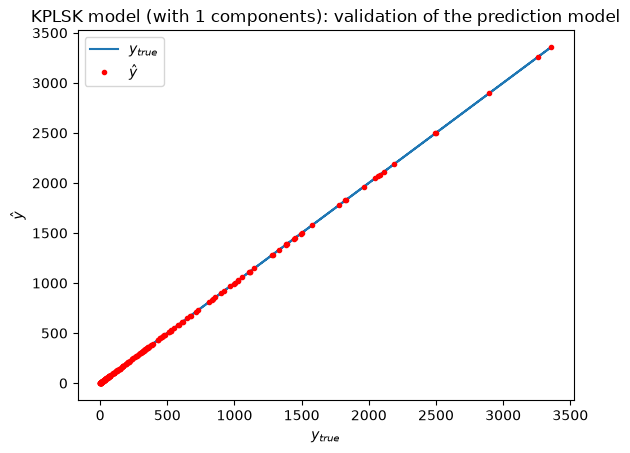

In [22]:
########### The KPLSK model

# 'n_comp' and 'theta0' must be an integer in [1,ndim[ and a list of length n_comp, respectively.

t = KPLSK(n_comp=2, theta0=[1e-2, 1e-2], print_prediction=False)
t.set_training_values(xt, yt)

t.train()

# Prediction of the validation points
y = t.predict_values(xtest)
print("KPLSK,  err: " + str(compute_relative_error(t, xtest, ytest)))

# plot prediction/true values
if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        f"KPLSK model (with {n_comp} components): validation of the prediction model"
    )

if plot_status:
    plt.show()

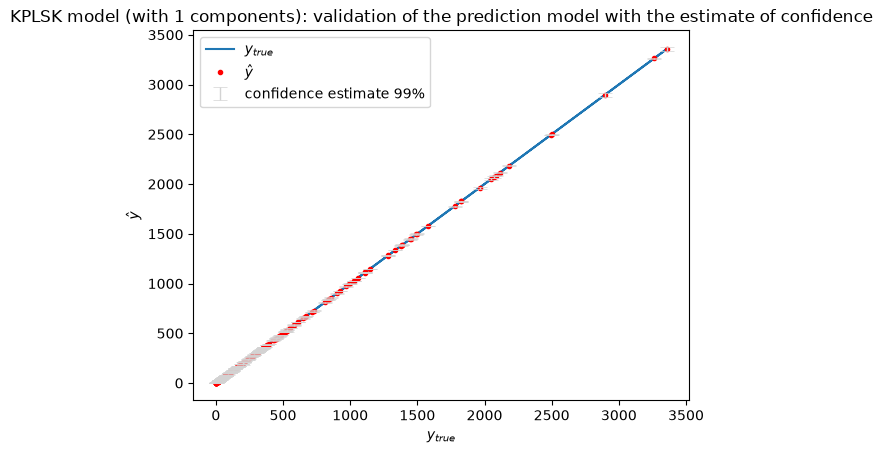

In [23]:
# estimated variance for the validation points
s2 = t.predict_variances(xtest)
# plot with the associated interval confidence
yerr = (
    2 * 3 * np.sqrt(s2)
)  # in order to use +/- 3 x standard deviation: 99% confidence interval estimation
if plot_status:
    # Plot the function, the prediction and the 99% confidence interval based on
    # the MSE
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")
    plt.errorbar(
        np.squeeze(ytest),
        np.squeeze(y),
        yerr=np.squeeze(yerr),
        fmt="none",
        capsize=5,
        ecolor="lightgray",
        elinewidth=1,
        capthick=0.5,
        label="confidence estimate 99%",
    )
    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        f"KPLSK model (with {n_comp} components): validation of the prediction model with the estimate of confidence"
    )

if plot_status:
    plt.show()

## 4.4 Kriging with cooperative components (CoopCompKRG)

### see also a dedicated Notebook in `tutorial/misc/SMT_CoopCompKRG.ipynb`

In [24]:
from smt.surrogate_models import CoopCompKRG

# Example with 2 random components in order to perform
# sub-optimization of theta in each of the component (ncomp <= ndim)
ncomp = 2
print("Dimension in each of the component", int(ndim / ncomp))
# Random design variable to component allocation
# the comp_var are directly randomly choosen in the model
# Cooperative components Kriging model fit
sm = CoopCompKRG(ncomp=ncomp)
sm.set_training_values(xt, yt)
sm.train()

Dimension in each of the component 1
___________________________________________________________________________
   
                      Cooperative Components Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.3983569


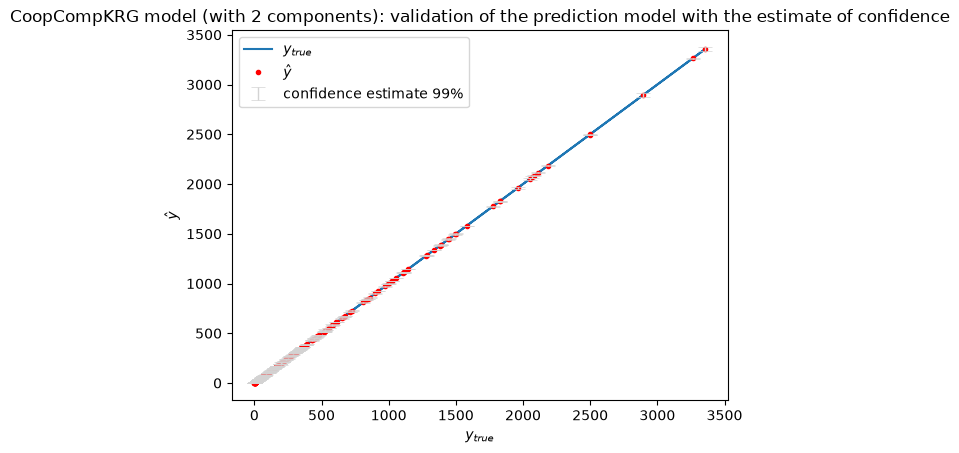

In [25]:
# estimated variance for the validation points
s2 = t.predict_variances(xtest)
# plot with the associated interval confidence
yerr = (
    2 * 3 * np.sqrt(s2)
)  # in order to use +/- 3 x standard deviation: 99% confidence interval estimation
if plot_status:
    # Plot the function, the prediction and the 99% confidence interval based on
    # the MSE
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")
    plt.errorbar(
        np.squeeze(ytest),
        np.squeeze(y),
        yerr=np.squeeze(yerr),
        fmt="none",
        capsize=5,
        ecolor="lightgray",
        elinewidth=1,
        capthick=0.5,
        label="confidence estimate 99%",
    )
    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        f"CoopCompKRG model (with {ncomp} components): "
        "validation of the prediction model with the estimate of confidence"
    )

if plot_status:
    plt.show()

# 5. IDW Model
Here we implement the IDW model.

___________________________________________________________________________
   
                                    IDW
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
   Training - done. Time (sec):  0.0000000
IDW,  err: 0.4851637249919936


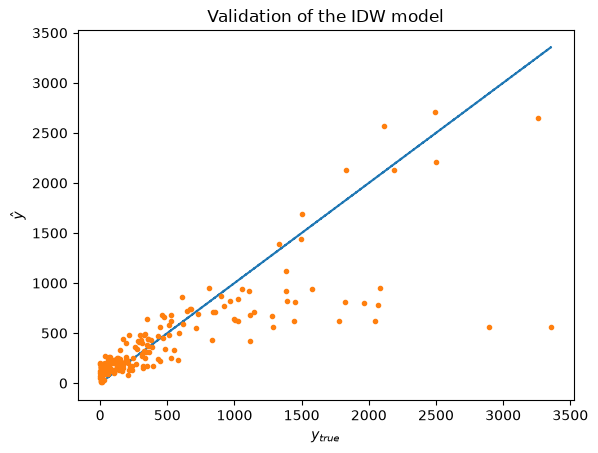

In [26]:
if compiled_available:
    ########### The IDW model

    t = IDW(print_prediction=False)
    t.set_training_values(xt, yt)

    t.train()

    # Prediction of the validation points
    y = t.predict_values(xtest)
    print("IDW,  err: " + str(compute_relative_error(t, xtest, ytest)))
    if plot_status:
        plt.figure()
        plt.plot(ytest, ytest, "-.")
        plt.plot(ytest, y, ".")
        plt.xlabel(r"$y_{true}$")
        plt.ylabel(r"$\hat{y}$")
        plt.title("Validation of the IDW model")
        plt.show()

# 6. RBF Model
Here we implement the RBF model.

___________________________________________________________________________
   
                                    RBF
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
      Initializing linear solver ...
         Performing LU fact. (21 x 21 mtx) ...
         Performing LU fact. (21 x 21 mtx) - done. Time (sec):  0.0000000
      Initializing linear solver - done. Time (sec):  0.0000000
      Solving linear system (col. 0) ...
         Back solving (21 x 21 mtx) ...
         Back solving (21 x 21 mtx) - done. Time (sec):  0.0062926
      Solving linear system (col. 0) - done. Time (sec):  0.0062926
   Training - done. Time (sec):  0.0062926
RBF,  err: 0.3631980018589721


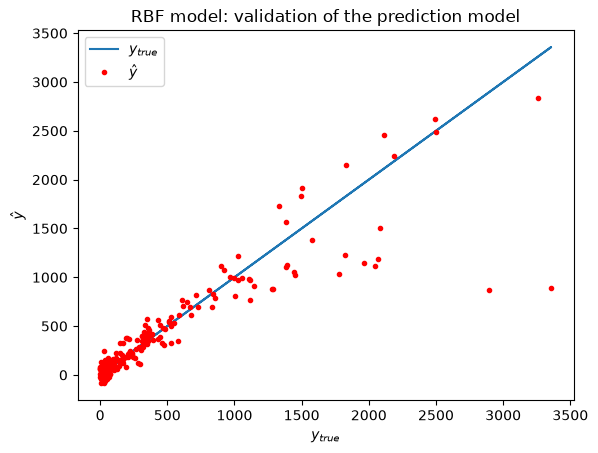

In [27]:
if compiled_available:
    ########### The RBF model

    t = RBF(print_prediction=False, poly_degree=0)
    t.set_training_values(xt, yt)

    t.train()

    # Prediction of the validation points
    y = t.predict_values(xtest)
    print("RBF,  err: " + str(compute_relative_error(t, xtest, ytest)))
    # Plot prediction/true values
    if plot_status:
        fig = plt.figure()
        plt.plot(ytest, ytest, "-", label="$y_{true}$")
        plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

        plt.xlabel("$y_{true}$")
        plt.ylabel(r"$\hat{y}$")

        plt.legend(loc="upper left")
        plt.title("RBF model: validation of the prediction model")

# 7. RMTS Models

The RMTB and RMTC models are suitable for low-dimensional problems.

## 7.1 RMTB Model

___________________________________________________________________________
   
                                   RMTB
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
      Pre-computing matrices ...
         Computing dof2coeff ...
         Computing dof2coeff - done. Time (sec):  0.0000000
         Initializing Hessian ...
         Initializing Hessian - done. Time (sec):  0.0002315
         Computing energy terms ...
         Computing energy terms - done. Time (sec):  0.0000000
         Computing approximation terms ...
         Computing approximation terms - done. Time (sec):  0.0070436
      Pre-computing matrices - done. Time (sec):  0.0072751
      Solving for degrees of freedom ...
         Solving initial startup problem (n=225) ...
            Solving for output 0 ...
       

               Iteration (num., iy, grad. norm, func.) :   3   0 1.141943447e-01 4.457217145e+01
               Iteration (num., iy, grad. norm, func.) :   4   0 3.448048567e-02 4.448592397e+01
               Iteration (num., iy, grad. norm, func.) :   5   0 6.846340683e-03 4.446978794e+01
               Iteration (num., iy, grad. norm, func.) :   6   0 6.359048063e-04 4.446354897e+01
               Iteration (num., iy, grad. norm, func.) :   7   0 4.068957621e-04 4.446340279e+01
               Iteration (num., iy, grad. norm, func.) :   8   0 2.516141613e-04 4.446246760e+01
               Iteration (num., iy, grad. norm, func.) :   9   0 1.264660071e-04 4.446245602e+01
               Iteration (num., iy, grad. norm, func.) :  10   0 9.973390465e-05 4.446245207e+01
               Iteration (num., iy, grad. norm, func.) :  11   0 1.233548102e-05 4.446244761e+01
               Iteration (num., iy, grad. norm, func.) :  12   0 2.369125997e-05 4.446244733e+01
               Iteration (num.

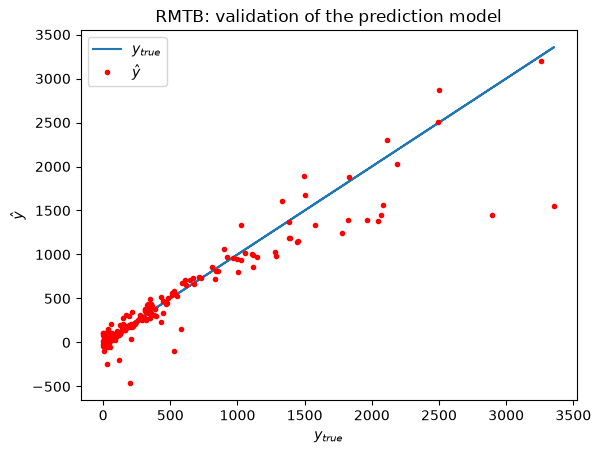

In [28]:
if compiled_available:
    ########### The RMTB model

    t = RMTB(
        xlimits=fun.xlimits,
        min_energy=True,
        nonlinear_maxiter=20,
        print_prediction=False,
    )
    t.set_training_values(xt, yt)
    # Add the gradient information
    #    for i in range(ndim):
    #        t.set_training_derivatives(xt,yt[:, 1+i].reshape((yt.shape[0],1)),i)
    t.train()

    # Prediction of the validation points
    y = t.predict_values(xtest)
    print("RMTB,  err: " + str(compute_relative_error(t, xtest, ytest)))
    # plot prediction/true values
    if plot_status:
        fig = plt.figure()
        plt.plot(ytest, ytest, "-", label="$y_{true}$")
        plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

        plt.xlabel("$y_{true}$")
        plt.ylabel(r"$\hat{y}$")

        plt.legend(loc="upper left")
        plt.title("RMTB: validation of the prediction model")

    if plot_status:
        plt.show()

## 7.2 RMTC Model

___________________________________________________________________________
   
                                   RMTC
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
      Pre-computing matrices ...
         Computing dof2coeff ...
         Computing dof2coeff - done. Time (sec):  0.0000000
         Initializing Hessian ...
         Initializing Hessian - done. Time (sec):  0.0000000
         Computing energy terms ...
         Computing energy terms - done. Time (sec):  0.0000000
         Computing approximation terms ...
         Computing approximation terms - done. Time (sec):  0.0000000
      Pre-computing matrices - done. Time (sec):  0.0000000
      Solving for degrees of freedom ...
         Solving initial startup problem (n=100) ...
            Solving for output 0 ...
       

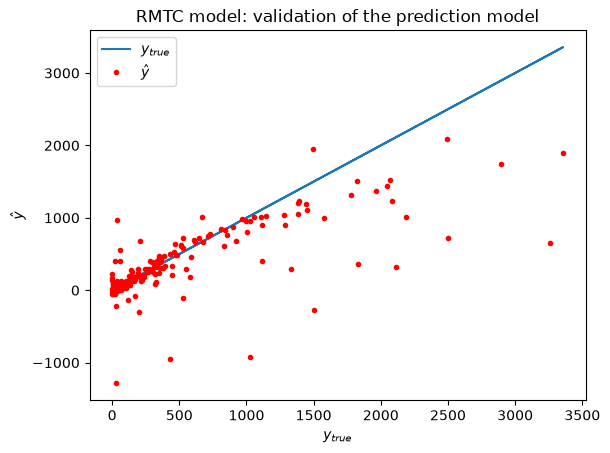

In [29]:
if compiled_available:
    ########### The RMTC model

    t = RMTC(
        xlimits=fun.xlimits,
        min_energy=True,
        nonlinear_maxiter=20,
        print_prediction=False,
    )
    t.set_training_values(xt, yt)
    #    # Add the gradient information
    #    for i in range(ndim):
    #        t.set_training_derivatives(xt,yt[:, 1+i].reshape((yt.shape[0],1)),i)

    t.train()

    # Prediction of the validation points
    y = t.predict_values(xtest)
    print("RMTC,  err: " + str(compute_relative_error(t, xtest, ytest)))
    # plot prediction/true values
    if plot_status:
        fig = plt.figure()
        plt.plot(ytest, ytest, "-", label="$y_{true}$")
        plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

        plt.xlabel("$y_{true}$")
        plt.ylabel(r"$\hat{y}$")

        plt.legend(loc="upper left")
        plt.title("RMTC model: validation of the prediction model")

    if plot_status:
        plt.show()

# 8. Computation of error metrics

We compute several types of error,  
- the  mean square error
$$
\text{MSE} = \sum\limits_{i=1}^{n_\text{test}}\left(y\left(\textbf{x}_{\text{test},i}\right)-\hat{y}\left(\textbf{x}_{\text{test},i}\right)\right)^2
$$
- the relative error (RE in %)
$$
\text{RE} = \frac{\sqrt{\sum\limits_{i=1}^{n_\text{test}}\left(y\left(\textbf{x}_{\text{test},i}\right)-\hat{y}\left(\textbf{x}_{\text{test},i}\right)\right)^2}}{\sqrt{\sum\limits_{i=1}^{n_{\text{test}}}\left(y\left(\textbf{x}_{\text{test},i}\right)\right)^2}}100,
$$
-  the Coefficient of variation or Coefficient of correlation (R2)
$$
\text{R2} = 1- \frac{{\sum\limits_{i=1}^{n_\text{test}}\left(y\left(\textbf{x}_{\text{test},i}\right)-\hat{y}\left(\textbf{x}_{\text{test},i}\right)\right)^2}}{{\sum\limits_{i=1}^{n_{\text{test}}}\left(y\left(\textbf{x}_{\text{test},i}  \right)- \bar y \right)^2}},
$$
where  ${\displaystyle {\bar {y}}}$  is the mean of the observed data:
$${\bar {y}}=\frac {1}{n_{\text{test}}}\sum _{i=1}^{n_{\text{test}}}{y}\left(\textbf{x}_{\text{test},i}\right)$$
An R2 of 1 indicates that the regression line perfectly fits the data.



More metrics computed in scikit-learn are given in http://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

# Prediction of the validation points
yval = t.predict_values(xtest)
# Prediction of the training  points
ytrain = t.predict_values(xt)

# The mean squared error
print("Mean squared error on validation data: %.2f" % mean_squared_error(ytest, yval))
# Explained variance score: 1 is perfect prediction
print("Variance score on training data: %.2f" % r2_score(yt, ytrain))

Mean squared error on validation data: 196826.95
Variance score on training data: 1.00


### Other  performance functions available in SMT

#### Q2
$Q2$ for  Predictive ($R2$) assesses the model's predictive power, typically on validation or test data. It is similar to $R2$ but emphasizes how well the model predicts unseen data.


##### Key Difference:
* $Q2$ evaluates the model's performance on unseen data (validation/test), while $R2$ evaluates performance on the training data.
* A high $Q2$ indicates good generalization ability.

* $Q2$ generally follows the same interpretation as $R2$, with higher values indicating better predictive performance.

 $$ Q2 = 1 - \displaystyle \frac{\sum _{i=1}^{n_{\text{test}}}\left(y\left(\textbf{x}_{\text{test},i}\right) - \hat{y}(\left(\textbf{x}_{\text{test},i}\right)\right)^2}{\sum_{i=1}^{{n_{\text{test}}}} \left(y\left(\textbf{x}_{\text{test},i}  \right)- \bar y \right)^2}$$

where  ${\displaystyle {\bar {y}}}$  is the mean of the observed data:

$${\bar {y}}=\frac {1}{n_{\text{test}}}\sum _{i=1}^{n_{\text{test}}}{y}\left(\textbf{x}_{\text{test},i}\right)$$

##### Key Points:
* Both $Q2$ and $R2$ are bounded metrics with values between $-\infty$ and 1.
* $R2$ focuses on explanatory power (training set), while $Q2$  focuses on predictive power (validation/test set).
* A model can have a high $R2$ but a low $Q2$, indicating overfitting


### Predicted Variance Adequation for Kriging based models
$$ PVA = |  \log \frac{1}{n_{\text{test}}}\sum_{i=1}^{n_{\text{test}}} \frac{ \left(y\left(\textbf{x}_{\text{test},i}\right)- \hat{y}_{-i}(\left(\textbf{x}_{\text{test},i}\right)\right)^2}{{\hat s}^2_{-i}}| $$

where $(\hat{y}_{-i}, {\hat s}^2_{-i}) $ is the GP model computed without the $i$-th point in the training set.

PVA helps to check if the conditional GP variance is of the right order of magnitude: the smaller the PVA, the more reliable the prediction intervals.  More information here: Bachoc, F. (2013). Cross validation and maximum likelihood estimations of hyper-parameters of Gaussian processes with model misspecification. Computational Statistics & Data Analysis, 66, 55-69. "The smaller the PVA is, the better it is because the predictive variances are globally of the same order than the prediction errors, so that the confidence intervals are reliable. We use the logarithm in order to give the same weight to relative overestimation and to relative underestimation of the prediction errors."


In [31]:
from smt.utils.misc import compute_q2, compute_pva, compute_rmse

# For  a KRG model to get variance
t = KRG(theta0=[1e-2] * ndim, print_prediction=False)
t.set_training_values(xt, yt)
t.train()
# Prediction of the validation points
y = t.predict_values(xtest)

rmse = compute_rmse(t, xtest, ytest)
print("RMSE ", rmse)
q2 = compute_q2(t, xtest, ytest)
print("Q2 ", q2)
pva = compute_pva(t, xtest, ytest)
print("Predicted Variance Analysis ", pva)

___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.6757259
RMSE  0.41359132218729855
Q2  0.9999995916800942
Predicted Variance Analysis  1.2340201067241683


# 9. Use of derivatives

Generate the data for the training and the test set

In [32]:
# Computation of the gradient for the DOE points
# Compute the gradient
yt = fun(xt)
for i in range(ndim):
    yd = fun(xt, kx=i)
    yt = np.concatenate((yt, yd), axis=1)

ydtest = np.zeros((ntest, ndim))
for i in range(ndim):
    ydtest[:, i] = fun(xtest, kx=i).T

# 9.1 GEKPLS model using 2 PLS components and 1 approximating point

Training phase

In [33]:
from smt.surrogate_models import DesignSpace

########### The GEKPLS model using 1 approximating point and 2 components
design_space = DesignSpace(fun.xlimits)
# 'n_comp' must be an integer in [1,ndim[,  'theta0' a list of n_comp values
n_comp = 2
t = GEKPLS(
    n_comp=n_comp,
    theta0=n_comp * [1e-2],
    design_space=design_space,
    delta_x=1e-2,
    extra_points=1,
    print_prediction=False,
)
t.set_training_values(xt, yt[:, 0])
# Add the gradient information
for i in range(ndim):
    t.set_training_derivatives(xt, yt[:, 1 + i].reshape((yt.shape[0], 1)), i)

t.train()

___________________________________________________________________________
   
                                  GEKPLS
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.8262177


Prediction phase for the function

GEKPLS1,  err: 0.003272702727869255


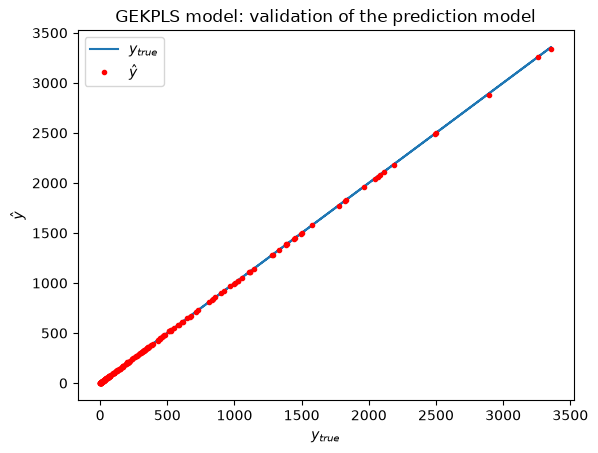

In [34]:
# Prediction of the validation points
y = t.predict_values(xtest)
print("GEKPLS1,  err: " + str(compute_relative_error(t, xtest, ytest)))
if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title("GEKPLS model: validation of the prediction model")

Prediction phase for the derivatives

GEKPLS1, err of the 1-th derivative: 0.00523502955809303


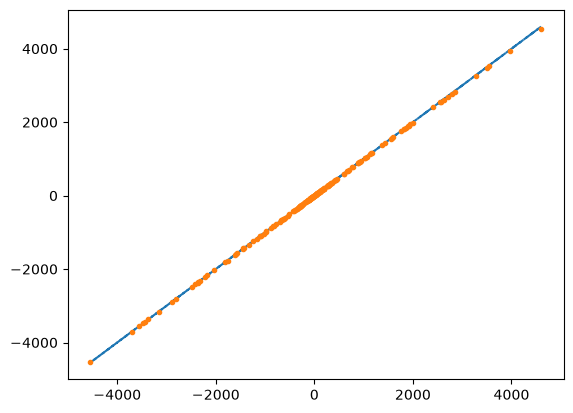

GEKPLS1, err of the 2-th derivative: 0.008375513717903602


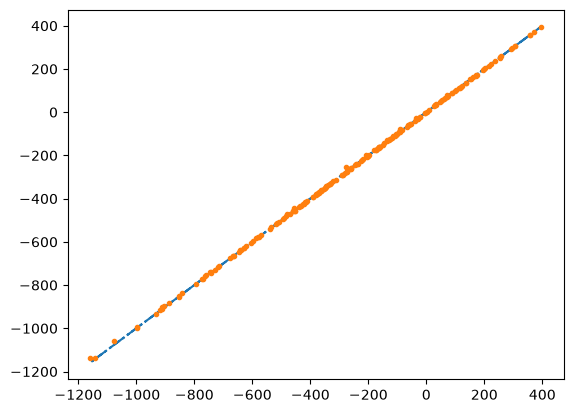

In [35]:
# Prediction of the derivatives with regards to each direction space
yd_prediction = np.zeros((ntest, ndim))
for i in range(ndim):
    yd_prediction[:, i] = t.predict_derivatives(xtest, kx=i).T
    print(
        "GEKPLS1, err of the "
        + str(i + 1)
        + "-th derivative: "
        + str(compute_relative_error(t, xtest, ydtest[:, i], kx=i))
    )

    if plot_status:
        plt.plot(ydtest[:, i], ydtest[:, i], "-.")
        plt.plot(ydtest[:, i], yd_prediction[:, i], ".")

    if plot_status:
        plt.show()

# 9.2 GEKPLS model using 2 PLS components and 2 approximating points

Training phase

In [36]:
# 'n_comp' must be an integer in [2,ndim[,  'theta0' a list of n_comp values
########### The GEKPLS model using 1 approximating point and 2 components
design_space = DesignSpace(fun.xlimits)
# 'n_comp' must be an integer in [1,ndim[,  'theta0' a list of n_comp values
n_comp = 2
t = GEKPLS(
    n_comp=n_comp,
    theta0=n_comp * [1e-2],
    design_space=design_space,
    delta_x=1e-2,
    extra_points=2,
    print_prediction=False,
)

t.set_training_values(xt, yt[:, 0])
# Add the gradient information
for i in range(ndim):
    t.set_training_derivatives(xt, yt[:, 1 + i].reshape((yt.shape[0], 1)), i)

t.train()

___________________________________________________________________________
   
                                  GEKPLS
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.7460465


Prediction for the function

GEKPLS2,  err: 0.006084515931590891


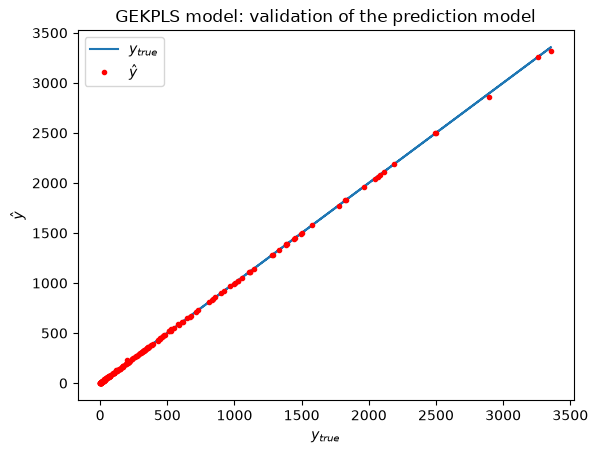

In [37]:
# Prediction of the validation points
y = t.predict_values(xtest)
print("GEKPLS2,  err: " + str(compute_relative_error(t, xtest, ytest)))
if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title("GEKPLS model: validation of the prediction model")

Prediction for the derivatives

GEKPLS2, err of the 1-th derivative: 0.009727190139376658


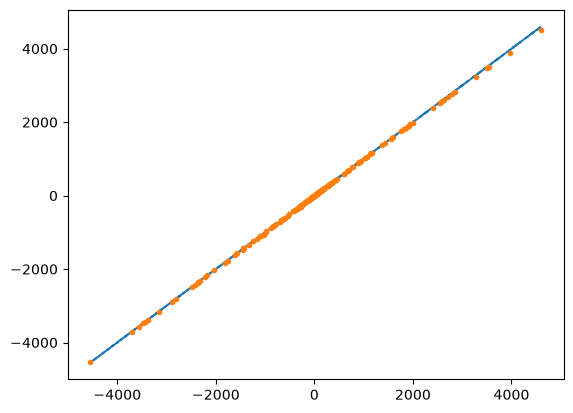

GEKPLS2, err of the 2-th derivative: 0.017781657397999646


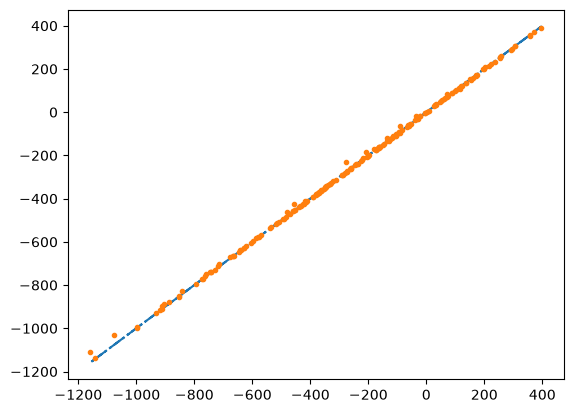

In [38]:
# Prediction of the derivatives with regards to each direction space
yd_prediction = np.zeros((ntest, ndim))
for i in range(ndim):
    yd_prediction[:, i] = t.predict_derivatives(xtest, kx=i).T
    print(
        "GEKPLS2, err of the "
        + str(i + 1)
        + "-th derivative: "
        + str(compute_relative_error(t, xtest, ydtest[:, i], kx=i))
    )

    if plot_status:
        plt.plot(ydtest[:, i], ydtest[:, i], "-.")
        plt.plot(ydtest[:, i], yd_prediction[:, i], ".")

    if plot_status:
        plt.show()

# 10. Marginal Gaussian Process for high dimensional input space

To use MGP, the input space must be normalized $x \in [-1,1]^d$

___________________________________________________________________________
   
                                    MGP
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.5515230
MGP,  err: 1.7782405480538612


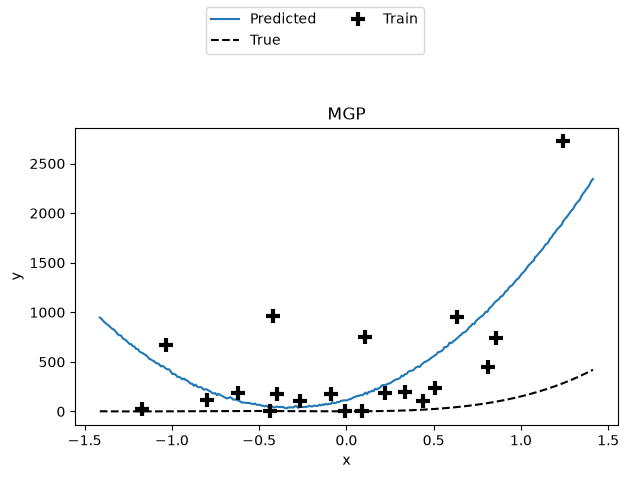

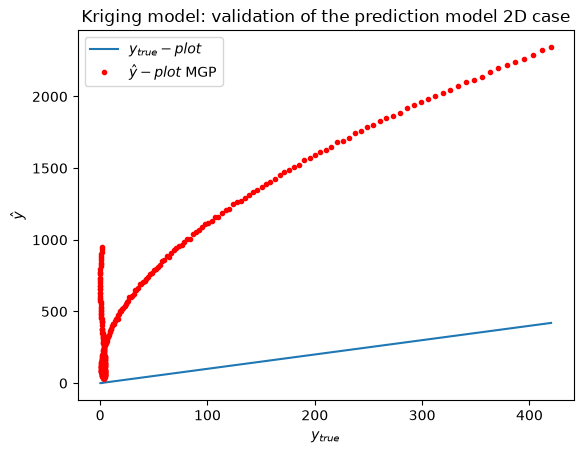

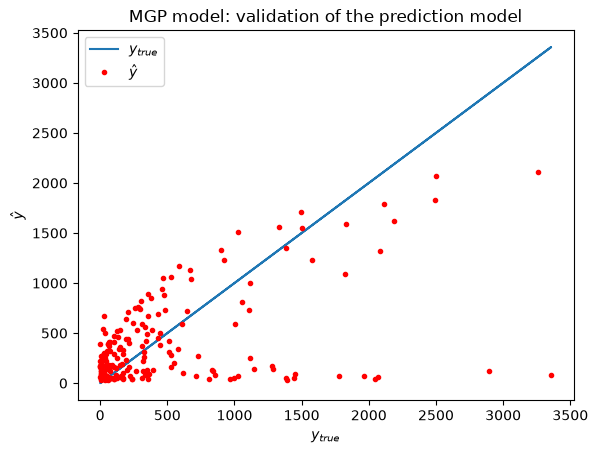

In [39]:
n_comp = 1
# To  use MGP the input space must be in [-1, 1]^d, so here we divide by 2
x_train = xt / 2
y_train = yt[:, 0]
x_test = xtest / 2

t = MGP(n_comp=n_comp, theta0=[1e-2] * n_comp * ndim, print_prediction=False)
t.set_training_values(x_train, y_train)
t.train()

# Get the transfer matrix A: u=Ax
emb = t.embedding["C"]
u_train = t.get_u_from_x(x_train)

# Compute the smallest box containing all points of A  (dimension = n_comp)
upper = np.sum(np.abs(emb), axis=0)
lower = -upper

# To have some points to validat on a plot
n_plot = 300
u_plot = np.zeros((n_plot, n_comp))
for ii in range(n_comp):
    u_plot[:, ii] = np.atleast_2d(
        np.linspace(lower[ii], upper[ii], n_plot)
    )  # u_plot is in dimension = n_comp

x_plot = t.get_x_from_u(u_plot)  # Get corresponding points in Omega (dimension = ndim)
y_plot_true = fun(x_plot)
y_plot_pred = t.predict_values(x_plot)
sigma_MGP = t.predict_variances(x_plot)

y = t.predict_values(x_test)

# Prediction of the validation points
print("MGP,  err: " + str(compute_relative_error(t, xtest, ytest)))

# Plots if n_comp=1
if n_comp == 1:
    fig, ax = plt.subplots()
    ax.plot(u_plot, y_plot_pred, label="Predicted")
    ax.plot(u_plot, y_plot_true, "k--", label="True")
    ax.plot(u_train, y_train, "k+", mew=3, ms=10, label="Train")

    ax.set(xlabel="x", ylabel="y", title="MGP")
    fig.legend(loc="upper center", ncol=2)
    fig.tight_layout()
    fig.subplots_adjust(top=0.74)
    plt.show()

    # plot prediction/true values
    fig = plt.figure()
    plt.plot(y_plot_true, y_plot_true, "-", label="$y_{true}-plot$")
    plt.plot(y_plot_true, y_plot_pred, "r.", label=r"$\hat{y}-plot$ MGP")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title("Kriging model: validation of the prediction model 2D case")


if plot_status:
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title("MGP model: validation of the prediction model")

if plot_status:
    plt.show()

# 11. Multiple outputs

<div class="alert alert-info fade in" id="d110">
In cas you have multiple outputs $y \in \mathbb{R}^{n_y}$, one possibility is to add an external loop.  The correlations between ouputs are not taken into account.
    </div>

Output  0
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.6697102
Kriging,  err: 0.0005183506370863989


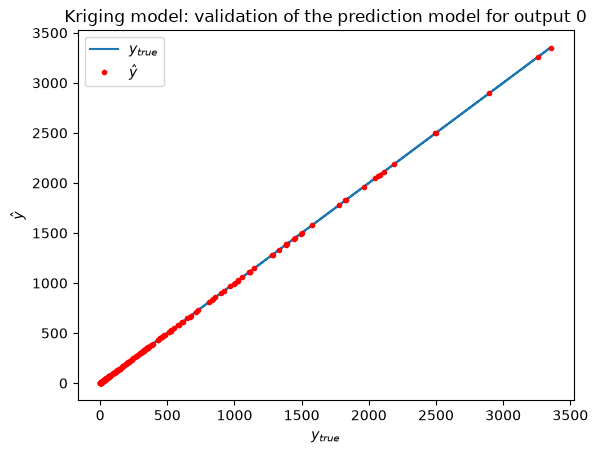

theta values for output  0  =  [0.02359944 0.00010136]
Output  1
___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.6469421
Kriging,  err: 0.0005183506370863989


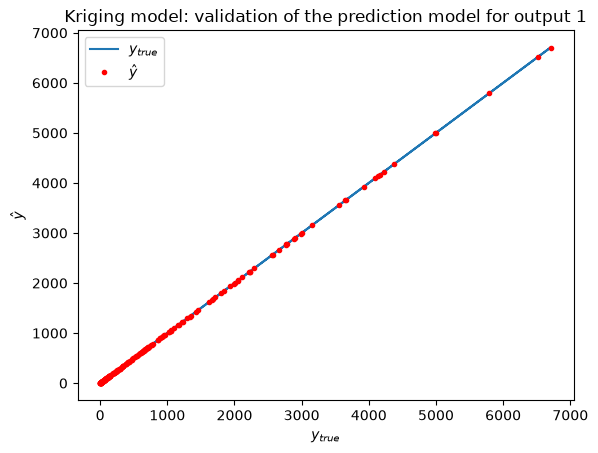

theta values for output  1  =  [0.02359944 0.00010136]


In [40]:
# Compute the ny outputs
yt = fun(xt)
ytest = fun(xtest)
# here y2= 2*y1
ny = 2
yt_ny = np.zeros((np.shape(yt)[0], ny))
for ii in range(ny):
    yt_ny[:, ii] = (ii + 1) * yt[:, 0]


# Construction of the validation points
ytest_ny = np.zeros((np.shape(ytest)[0], ny))
for ii in range(ny):
    ytest_ny[:, ii] = (ii + 1) * ytest[:, 0]

# To build a list of models
list_t = []
########### The Kriging model
for iny in range(ny):
    print("Output ", iny)
    # The variable 'theta0' is a list of length ndim.
    t = KRG(theta0=[1e-2] * ndim, print_prediction=False)
    t.set_training_values(xt, yt_ny[:, iny])

    t.train()
    list_t.append(t)

    # Prediction of the validation points
    y = t.predict_values(xtest)
    print("Kriging,  err: " + str(compute_relative_error(t, xtest, ytest_ny[:, iny])))
    if plot_status:
        # Plot the function, the prediction and the 95% confidence interval based on
        # the MSE
        fig = plt.figure()
        plt.plot(ytest_ny[:, iny], ytest_ny[:, iny], "-", label="$y_{true}$")
        plt.plot(ytest_ny[:, iny], y, "r.", label=r"$\hat{y}$")

        plt.xlabel("$y_{true}$")
        plt.ylabel(r"$\hat{y}$")

        plt.legend(loc="upper left")
        plt.title(
            "Kriging model: validation of the prediction model for output " + str(iny)
        )

    if plot_status:
        plt.show()

    # Value of theta
    print("theta values for output ", iny, " = ", t.optimal_theta)

<div class="alert alert-info fade in" id="d110">
Another possibility is to consider $y$ with multiple outputs but the correlations are not takin into account (similar as the external loop)
    </div>

___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 20
   
___________________________________________________________________________
   
 Training
   
   Training ...
fmin_cobyla failed but the best value is retained
   Training - done. Time (sec):  0.0180509
Kriging,  err: 0.9947560383159305


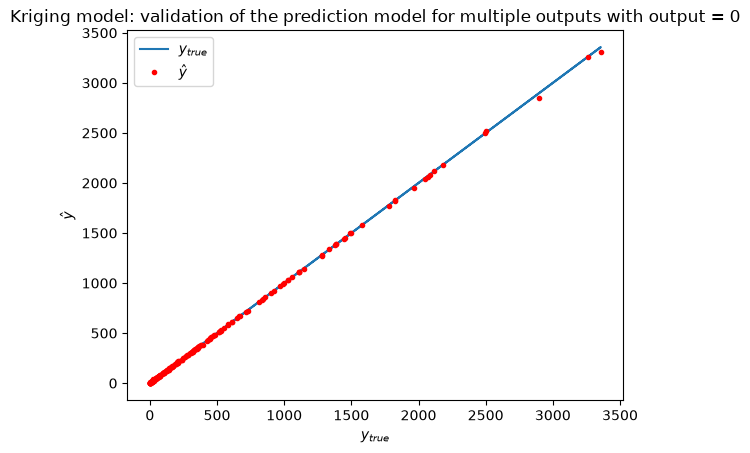

Kriging,  err: 0.5014044726213887


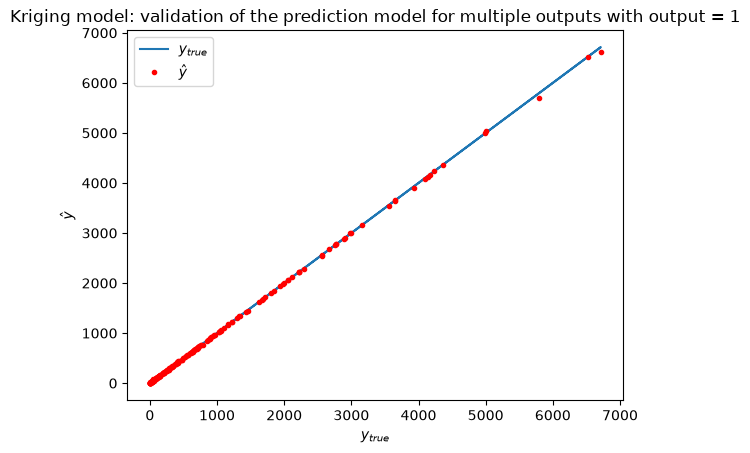

In [41]:
# Compute the ny outputs
# here y2= 2*y1
ny = 2
multiyt = np.hstack((yt, 2 * yt))
# Construction of the validation points
multiytest = np.hstack((ytest, 2 * ytest))

# The variable 'theta0' is a list of length ndim.
tmulti = KRG(theta0=[1e-2] * ndim, print_prediction=False)
tmulti.set_training_values(xt, multiyt)

tmulti.train()

# Prediction of the validation points
ymulti = tmulti.predict_values(xtest)

for iny in range(ny):
    print(
        "Kriging,  err: "
        + str(compute_relative_error(tmulti, xtest, multiytest[:, iny]))
    )
    if plot_status:
        # Plot the function, the prediction and the 95% confidence interval based on
        # the MSE
        fig = plt.figure()
        plt.plot(multiytest[:, iny], multiytest[:, iny], "-", label="$y_{true}$")
        plt.plot(multiytest[:, iny], ymulti[:, iny], "r.", label=r"$\hat{y}$")

        plt.xlabel("$y_{true}$")
        plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        "Kriging model: validation of the prediction model for multiple outputs with output = "
        + str(iny)
    )

    if plot_status:
        plt.show()

Between the two methods the error is different!

# 12. Mixture of experts to compare different surrogate models

MOE enabled experts:  ['KRG', 'LS', 'QP']


Kriging 0.28084528032333445
LS 390.98132238201185
QP 184.83491729368237
Best expert = Kriging


Best model found with MOE Kriging
Correlation parameter of this model: squar_exp
Regression parameter of this model: constant
MOE + 1 cluster,  err: 0.00046796515312004104


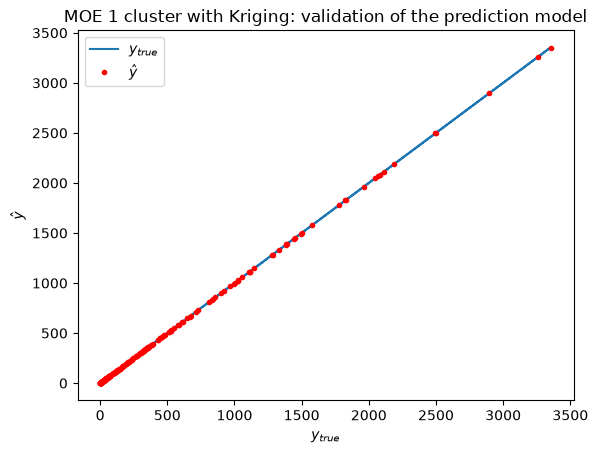

In [42]:
from smt.applications import MOE

# Only 1 cluster is considered and the surroagte models are compared on a test set from the training database
moe = MOE(n_clusters=1)
moe = MOE(n_clusters=1, xtest=xtest, ytest=ytest)

# to choose some restrictions of the available models use allow option
moe = MOE(n_clusters=1, allow=["KRG", "LS", "QP"])

print("MOE enabled experts: ", moe.enabled_experts)


moe.set_training_values(xt, yt[:, 0])
moe.train()


print("Best model found with MOE", moe._experts[0].name)
if (
    (moe._experts[0].name == "Kriging")
    or (moe._experts[0].name == "KPLS")
    or (moe._experts[0].name == "KPLSK")
):
    print("Correlation parameter of this model:", moe._experts[0].options["corr"])
    print("Regression parameter of this model:", moe._experts[0].options["poly"])


# Prediction of the validation points
y = moe.predict_values(xtest)
print("MOE + 1 cluster,  err: " + str(compute_relative_error(moe, xtest, ytest)))
if plot_status:
    # Plot the function, the prediction and the 95% confidence interval based on
    # the MSE
    fig = plt.figure()
    plt.plot(ytest, ytest, "-", label="$y_{true}$")
    plt.plot(ytest, y, "r.", label=r"$\hat{y}$")

    plt.xlabel("$y_{true}$")
    plt.ylabel(r"$\hat{y}$")

    plt.legend(loc="upper left")
    plt.title(
        "MOE 1 cluster with "
        + str(moe._experts[0].name)
        + ": validation of the prediction model"
    )

if plot_status:
    plt.show()


# to add a validation set (xtest,ytest) in order to compare different surrogate models

# 13. Saving surrogate models

As written in the documentation (https://smt.readthedocs.io/en/latest/_src_docs/surrogate_models.html), you can save some surrogate models

In [43]:
import pickle

# For saving models written in Python
filename = "moe.pkl"
with open(filename, "wb") as f:
    pickle.dump(moe, f)
# For loading the model
moe_load = None
with open(filename, "rb") as f:
    moe_load = pickle.load(f)

# to use the surrogate model
y_load = moe_load.predict_values(xtest)
print(y[1:10])
print(y_load[1:10])

[[7.42736863e+01]
 [2.72299296e+00]
 [6.85823252e+01]
 [3.26294391e+03]
 [1.10914280e+03]
 [2.37505880e+02]
 [2.82043201e+00]
 [2.89408007e+03]
 [1.62744133e+02]]
[[7.42736863e+01]
 [2.72299296e+00]
 [6.85823252e+01]
 [3.26294391e+03]
 [1.10914280e+03]
 [2.37505880e+02]
 [2.82043201e+00]
 [2.89408007e+03]
 [1.62744133e+02]]


In [44]:
moe.save("moe.bin")

moe2 = KRG.load("moe.bin")
moe_load = moe2.predict_values(xtest)
print(y[1:10])
print(moe_load[1:10])

[[7.42736863e+01]
 [2.72299296e+00]
 [6.85823252e+01]
 [3.26294391e+03]
 [1.10914280e+03]
 [2.37505880e+02]
 [2.82043201e+00]
 [2.89408007e+03]
 [1.62744133e+02]]
[[7.42736863e+01]
 [2.72299296e+00]
 [6.85823252e+01]
 [3.26294391e+03]
 [1.10914280e+03]
 [2.37505880e+02]
 [2.82043201e+00]
 [2.89408007e+03]
 [1.62744133e+02]]


# 14.  Kriging with integer variables

In [45]:
from smt.surrogate_models import KRG
from smt.applications.mixed_integer import MixedIntegerKrigingModel
from smt.design_space.design_space import DesignSpace, IntegerVariable

In [46]:
# definition of the 1D function
def f(X):
    x = X[:, 0]
    return (x - 3.5) * np.sin((x - 3.5) / (np.pi))


bounds = np.array([[0, 25]])
npt = 26
Xsol = np.linspace(bounds[0][0], bounds[0][1], npt)
Xs = Xsol[:, np.newaxis]
Ysol = f(Xs)

In [47]:
# training the model
xdoe = np.atleast_2d([0, 1, 2, 4, 10, 18, 24]).T
ydoe = f(xdoe)
n_doe = xdoe.size


# to define the model
design_space = DesignSpace(
    [
        IntegerVariable(bounds[0][0], bounds[0][1]),
    ]
)
sm = MixedIntegerKrigingModel(surrogate=KRG(design_space=design_space, theta0=[1e-2]))

sm.set_training_values(xdoe, ydoe)
sm.train()

# predictions
xplot = np.atleast_2d(np.linspace(0, 25.0, 300)).T
yplot = f(np.floor(xplot))
y = sm.predict_values(xplot)  # predictive mean
var = sm.predict_variances(xplot)  # predictive variance

___________________________________________________________________________
   
                            MixedIntegerKriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 7
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  0.3749959
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 300
   
   Predicting ...
   Predicting - done. Time (sec):  0.0050845
   
   Prediction time/pt. (sec) :  0.0000169
   


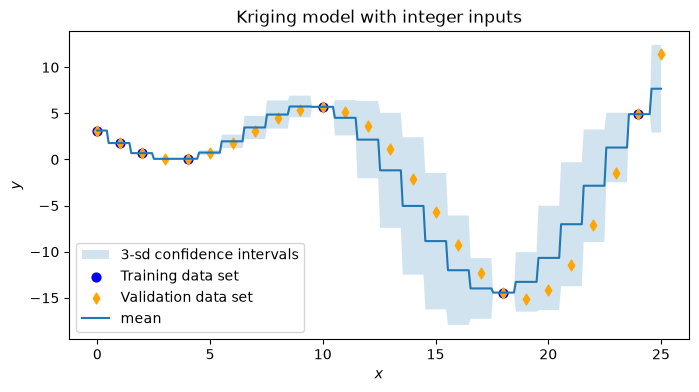

In [48]:
# plotting predictions +- 3 std confidence intervals
plt.rcParams["figure.figsize"] = [8, 4]
plt.fill_between(
    np.ravel(xplot),
    np.ravel(y - 3 * np.sqrt(var)),
    np.ravel(y + 3 * np.sqrt(var)),
    alpha=0.2,
    label="3-sd confidence intervals",
)
plt.scatter(xdoe, ydoe, marker="o", color="blue", s=40, label="Training data set")
plt.scatter(Xsol, Ysol, color="orange", marker="d", s=30, label="Validation data set")
plt.plot(xplot, y, label="mean")
plt.title("Kriging model with integer inputs")
plt.legend(loc=0)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.show()

<div class="alert alert-info fade in" id="d110">
To deal with mixed integer variables or mixed hierarchical variables, a dedicated notebook is available
    
    https://github.com/SMTorg/smt-notebooks/blob/master/SMT_MixedInteger_application.ipynb
    
</div>

# 15.  Kriging with a large database: Sparse GP

When the number of training points is too large,  the idea is to reduce the dimension of the correlation matrix by using inducing points.
    
If $N$ is is number of trianing points, sparse GPs consider a set of inducing points $M$ to approximate the posterior Gaussian distribution with a low-rank representation ($M << N$). Thus, this method enables accurate modeling of large datasets while preserving computational efficiency (typically time and memory for some chosen $M$).

In SMT two methods are used: Fully Independent Training Conditional (FITC) method and the Variational Free Energy (VFE) approximation are implemented inspired from inference methods developed in the GPy project (https://github.com/SheffieldML/GPy).


In [49]:
from smt.surrogate_models import SGP


def f_obj(x):
    import numpy as np

    return (
        np.sin(3 * np.pi * x)
        + 0.3 * np.cos(9 * np.pi * x)
        + 0.5 * np.sin(7 * np.pi * x)
    )


# random generator for reproducibility
rng = np.random.RandomState(0)

# Generate training data
nt = 200
# Variance of the gaussian noise on our trainingg data
eta2 = [0.01]
gaussian_noise = rng.normal(loc=0.0, scale=np.sqrt(eta2), size=(nt, 1))
xt = 2 * rng.rand(nt, 1) - 1
yt = f_obj(xt) + gaussian_noise

Here $N=200$  and we have to choose $M$

___________________________________________________________________________
   
                                    SGP
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 200
   
___________________________________________________________________________
   
 Training
   
   Training ...


   Training - done. Time (sec):  1.2148519
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 201
   
   Predicting ...
   Predicting - done. Time (sec):  0.0000000
   
   Prediction time/pt. (sec) :  0.0000000
   


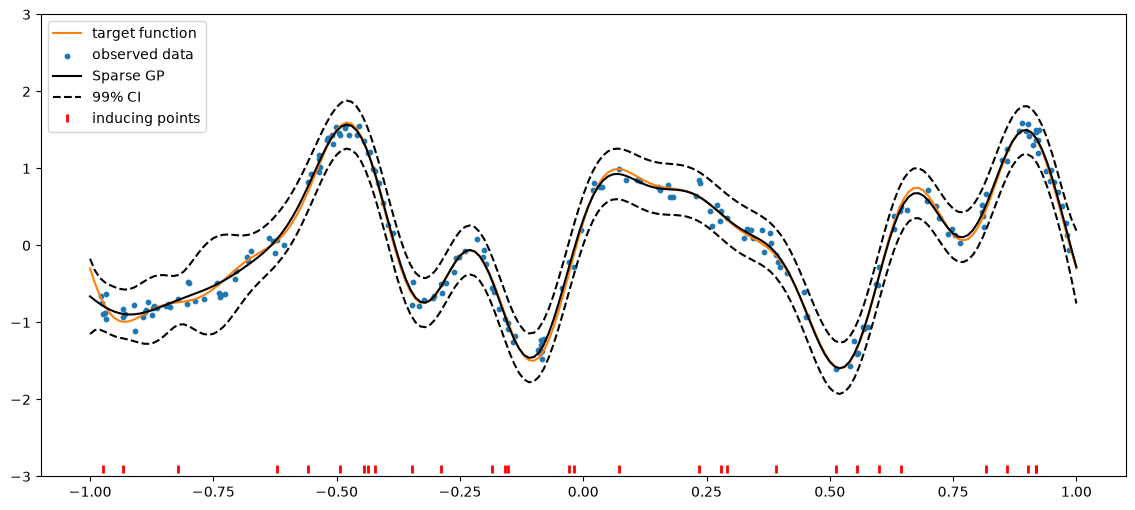

In [50]:
# Pick inducing points randomly in training data
n_inducing = 30
random_idx = rng.permutation(nt)[:n_inducing]
Z = xt[random_idx].copy()

sgp = SGP()
sgp.set_training_values(xt, yt)
sgp.set_inducing_inputs(Z=Z)
# sgp.set_inducing_inputs()  # When Z not specified n_inducing points are picked randomly in traing data
sgp.train()

x = np.linspace(-1, 1, nt + 1).reshape(-1, 1)
y = f_obj(x)
hat_y = sgp.predict_values(x)
var = sgp.predict_variances(x)

# plot prediction
plt.figure(figsize=(14, 6))
plt.plot(x, y, "C1-", label="target function")
plt.scatter(xt, yt, marker="o", s=10, label="observed data")
plt.plot(x, hat_y, "k-", label="Sparse GP")
plt.plot(x, hat_y - 3 * np.sqrt(var), "k--")
plt.plot(x, hat_y + 3 * np.sqrt(var), "k--", label="99% CI")
plt.plot(Z, -2.9 * np.ones_like(Z), "r|", mew=2, label="inducing points")
plt.ylim([-3, 3])
plt.legend(loc=0)
plt.show()

<div class="alert alert-info fade in" id="d110">
To deal with a large database, more information can be find here
    
`https://github.com/SMTorg/smt-sgp-paper`
        
with a dedicated notebook  available
    
   https://github.com/SMTorg/smt-sgp-paper/blob/main/sparse_gp_analytic.ipynb
    
</div>

and a associated paper https://www.mdpi.com/2226-4310/11/4/260

Valayer, H., Bartoli, N., Castaño-Aguirre, M., Lafage, R., Lefebvre, T., López-Lopera, A. F., & Mouton, S. (2024). A Python Toolbox for Data-Driven Aerodynamic Modeling Using Sparse Gaussian Processes. Aerospace, 11(4), 260.


# 16.  Kriging with GP build in Rust (GPX)

In [51]:
# to install the egobox dependency for the GP build in Rust
!pip install smt[gpx]

In [52]:
from smt.surrogate_models import GPX

xt = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
yt = np.array([0.0, 1.0, 1.5, 0.9, 1.0])

In [53]:
sm = GPX(theta0=[1e-2])
sm.set_training_values(xt, yt)
sm.train()

___________________________________________________________________________
   
                                    GPX
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 5
   
___________________________________________________________________________
   
 Training
   
   Training ...
   Training - done. Time (sec):  0.0442414


___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 100
   
   Predicting ...
   Predicting - done. Time (sec):  0.0017331
   
   Prediction time/pt. (sec) :  0.0000173
   
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 100
   
   Predicting ...
   Predicting - done. Time (sec):  0.0009997
   
   Prediction time/pt. (sec) :  0.0000100
   


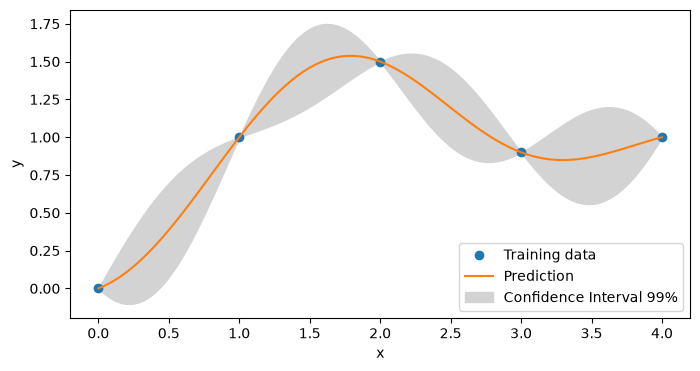

In [54]:
num = 100
x = np.linspace(0.0, 4.0, num)
y = sm.predict_values(x)
# estimated variance
s2 = sm.predict_variances(x)

_, axs = plt.subplots(1)
# add a plot with variance
axs.plot(xt, yt, "o")
axs.plot(x, y)
axs.fill_between(
    np.ravel(x),
    np.ravel(y - 3 * np.sqrt(s2)),
    np.ravel(y + 3 * np.sqrt(s2)),
    color="lightgrey",
)
axs.set_xlabel("x")
axs.set_ylabel("y")
axs.legend(
    ["Training data", "Prediction", "Confidence Interval 99%"],
    loc="lower right",
)

plt.show()

In [55]:
# to use KPLS to reduce the input dimension
sm2 = GPX(theta0=[1e-2], kpls_dim=1)
sm2.set_training_values(xt, yt)
sm2.train()

___________________________________________________________________________
   
                                    GPX
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 5
   
___________________________________________________________________________
   
 Training
   
   Training ...
   Training - done. Time (sec):  0.0019965


___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 100
   
   Predicting ...
   Predicting - done. Time (sec):  0.0009959
   
   Prediction time/pt. (sec) :  0.0000100
   
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 100
   
   Predicting ...
   Predicting - done. Time (sec):  0.0000000
   
   Prediction time/pt. (sec) :  0.0000000
   


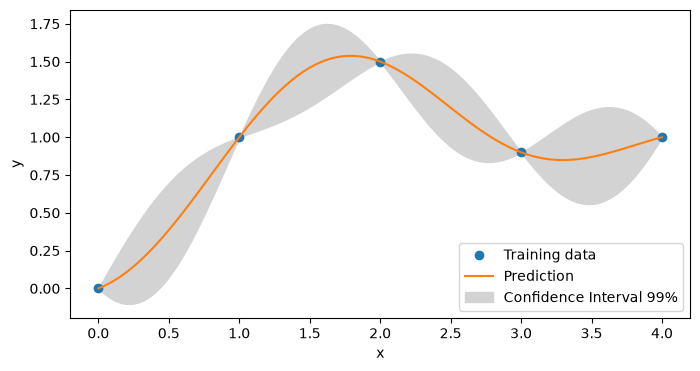

In [56]:
num = 100
x = np.linspace(0.0, 4.0, num)
y = sm2.predict_values(x)
# estimated variance
s2 = sm2.predict_variances(x)

_, axs = plt.subplots(1)
# add a plot with variance
axs.plot(xt, yt, "o")
axs.plot(x, y)
axs.fill_between(
    np.ravel(x),
    np.ravel(y - 3 * np.sqrt(s2)),
    np.ravel(y + 3 * np.sqrt(s2)),
    color="lightgrey",
)
axs.set_xlabel("x")
axs.set_ylabel("y")
axs.legend(
    ["Training data", "Prediction", "Confidence Interval 99%"],
    loc="lower right",
)

plt.show()